<a href="https://colab.research.google.com/github/MEpperley/MLP_Implementation_Code/blob/main/Linear_Regression_Coding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ======================
# Import libraries
# ======================
import random # Used for shuffling data
import torch # PyTorch library for tensor operations and automatic differentiation

In [ ]:
# ======================
# Generate synthetic dataset
# ======================
def synthetic_data(w, b, num_examples):
        X = torch.normal(0, 1, (num_examples, len(w)))
# Generate random feature matrix X with normal distribution (mean=0, std=1)
        y = torch.matmul(X, w) + b
# Compute linear relationship: y = Xw + b
        y += torch.normal(0, 0.01, y.shape)
# Add small Gaussian noise to simulate real-world data variation
        return X, y.reshape((-1, 1))
# Return features and reshape labels into column vector
true_w = torch.tensor([2.0, -3.4])
# Define the true weights used to generate the data
true_b = 4.2
# Define the true bias
features, labels = synthetic_data(true_w, true_b, 1000)
# Generate 1000 training examples
features[:5], labels[:5]
# Display the first 5 feature vectors and corresponding labels to verify data generation


(tensor([[ 2.5892,  0.0831],
         [ 0.8553, -0.7675],
         [-1.3088, -0.7637],
         [-1.0119,  0.5680],
         [-0.3520,  0.2448]]),
 tensor([[9.1017],
         [8.5170],
         [4.1925],
         [0.2438],
         [2.6716]]))

In [ ]:
# ======================
# Define data iterator (mini-batching)
# ======================
def data_iter(batch_size, features, labels):
        num_examples = len(features)
# Get total number of data points
        indices = list(range(num_examples))
# Create list of indices for data points
        random.shuffle(indices)
# Shuffle indices to randomize data order
        for i in range(0, num_examples, batch_size):
                batch_indices = torch.tensor(indices[i:min(i + batch_size, num_examples)])
# Select indices for the current batch
                yield features[batch_indices], labels[batch_indices]
# Yield a batch of features and labels
batch_size = 10
# Define number of samples per batch
 # Test iterator
for X, y in data_iter(batch_size, features, labels):
        print(X.shape, y.shape)
        break

torch.Size([10, 2]) torch.Size([10, 1])


In [ ]:
# ======================
# Initialize model parameters
# ======================
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
# Initialize weights randomly with small values and enable gradient tracking
b = torch.zeros(1, requires_grad=True)
# Initialize bias to zero and enable gradient tracking
w,b
# Display initial randomly generated weights and bias before training begins

(tensor([[-0.0091],
         [-0.0042]], requires_grad=True),
 tensor([0.], requires_grad=True))

In [ ]:
# ======================
# Define model
# ======================
def linreg(X, w, b):
        return torch.matmul(X, w) + b
# Linear regression model: compute predictions

In [ ]:
# ======================
# Define loss function (squared loss)
# ======================
def squared_loss(y_hat, y):
        return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2
# Compute squared error loss between predictions and actual values

In [ ]:
# ======================
# Define optimizer (Stochastic Gradient Descent)
# ======================
def sgd(params, lr, batch_size):
        with torch.no_grad():
# Disable gradient tracking during parameter updates
          for param in params:
                param -= lr * param.grad / batch_size
# Update parameters using gradient descent formula
                param.grad.zero_()
# Reset gradients to zero after update

In [ ]:
# ======================
# Training loop
# ======================
lr = 0.03
# Learning rate (step size for updates)
num_epochs = 5
# Number of times to iterate through the dataset
for epoch in range(num_epochs):
        for X, y in data_iter(batch_size, features, labels):
                l = squared_loss(linreg(X, w, b), y)
# Compute loss for current batch
                l.sum().backward()
# Compute gradients using backpropagation
                sgd([w, b], lr, batch_size)
# Update model parameters
        with torch.no_grad():
                train_l = squared_loss(linreg(features, w, b), labels)
# Compute loss over entire dataset
                print(f'epoch {epoch+1}, loss {float(train_l.mean()):.6f}')
# Print average loss for current epoch

epoch 1, loss 0.042064
epoch 2, loss 0.000154
epoch 3, loss 0.000050
epoch 4, loss 0.000049
epoch 5, loss 0.000049


In [ ]:
# ======================
# Compare learned vs true parameters
# ======================
print("Estimated w:", w.reshape(-1))
# Print learned weights
print("Estimated b:", b)
# Print learned bias
print("True w:", true_w)
# Print original weights
print("True b:", true_b)
# Print original bias

Estimated w: tensor([ 1.9993, -3.3995], grad_fn=<ViewBackward0>)
Estimated b: tensor([4.2000], requires_grad=True)
True w: tensor([ 2.0000, -3.4000])
True b: 4.2


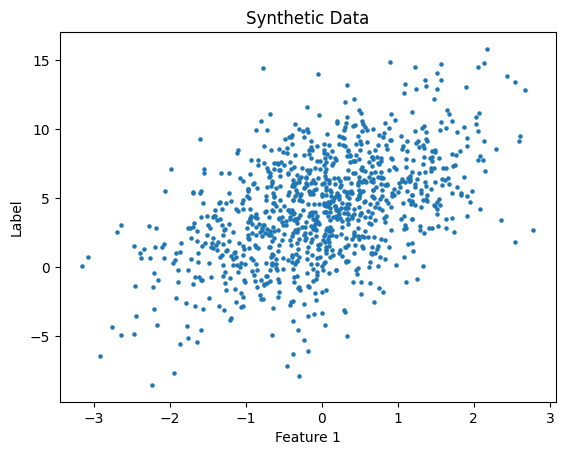

In [ ]:
# ======================
# Visualization
# ======================
import matplotlib.pyplot as plt
# Import plotting library
plt.scatter(features[:, 0].detach().numpy(), labels.detach().numpy(), s=5)
# Create scatter plot of first feature vs labels
plt.xlabel("Feature 1")
# Label x-axis
plt.ylabel("Label")
# Label y-axis
plt.title("Synthetic Data")
# Add title
plt.show()
# Display the plot